# Compare Binned-CV Width Sweep

This notebook compares the redshift-binned CV variants with inverse-bin-occupancy weighting for four choices of `cv-bin-width`:

- 0.1
- 0.2
- 0.4
- 0.5

The plotting logic follows the style used in `compare_inverse_density_rz.ipynb`.

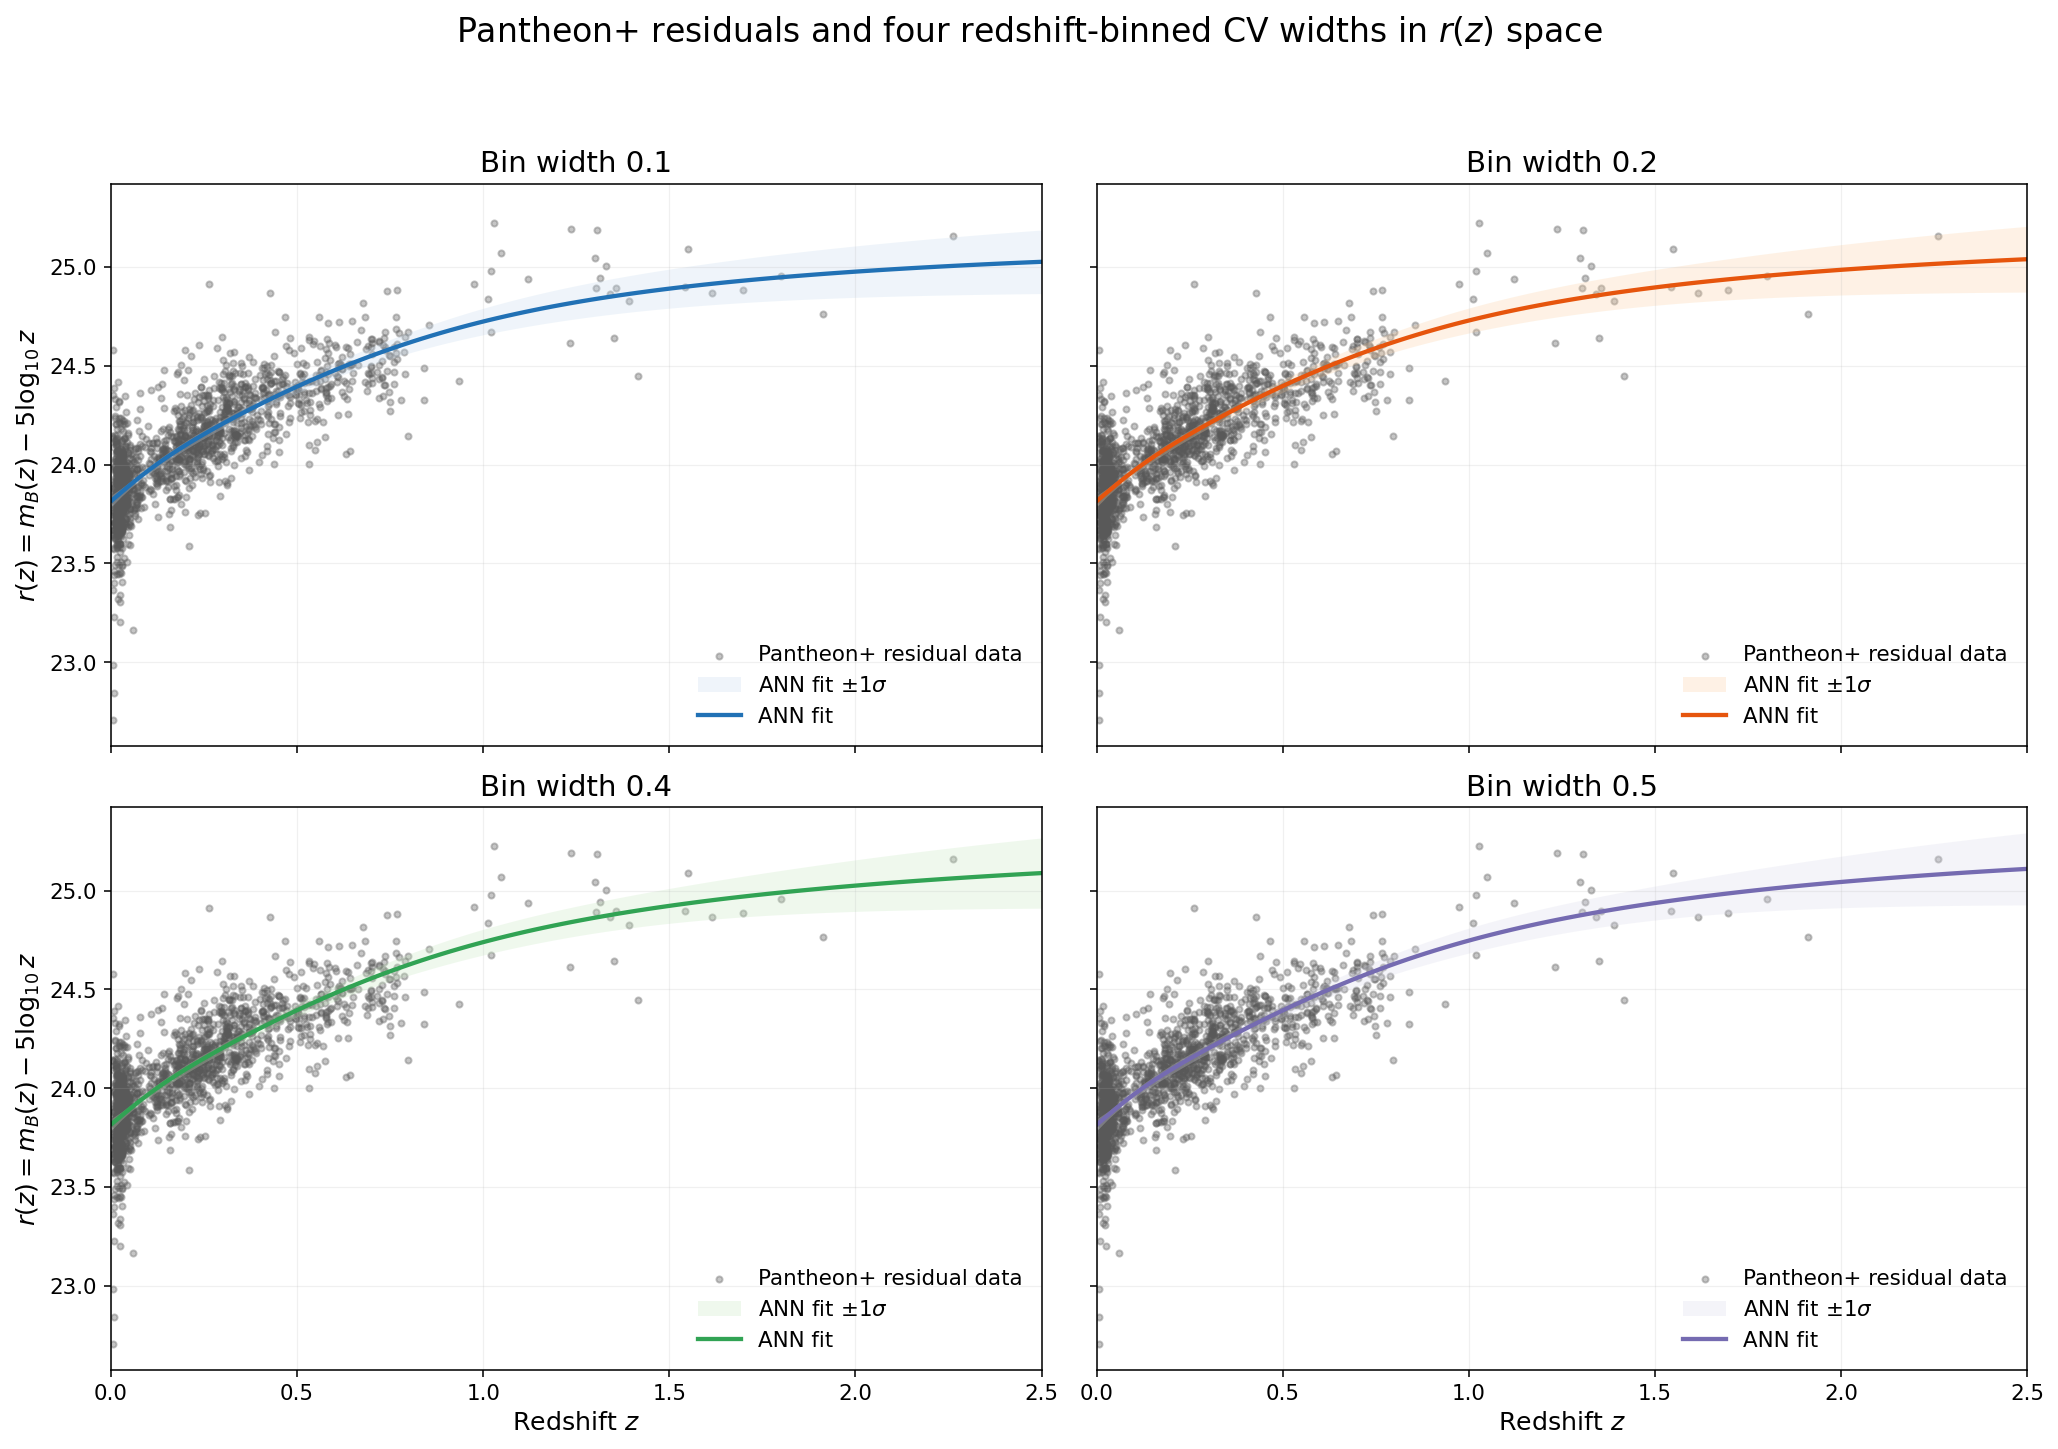

/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_width_rz_panels.png
/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_width_rz_panels.pdf


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root_dir = Path('/home/geng/Codes/sgl_cosmo/ann')
data_path = root_dir / 'data' / 'Pantheon+SH0ES.dat'
comparison_dir = root_dir / 'output' / 'binnedcv_width_comparison'
comparison_dir.mkdir(parents=True, exist_ok=True)

variant_info = {
    'Bin width 0.1': {
        'path': root_dir / 'output' / 'mb_ann_binnedcv_bw01_run' / 'pantheon_mb_ann_reconstruction.csv',
        'band': '#c6dbef',
        'line': '#2171b5',
    },
    'Bin width 0.2': {
        'path': root_dir / 'output' / 'mb_ann_binnedcv_bw02_run' / 'pantheon_mb_ann_reconstruction.csv',
        'band': '#fdd0a2',
        'line': '#e6550d',
    },
    'Bin width 0.4': {
        'path': root_dir / 'output' / 'mb_ann_binnedcv_bw04_run' / 'pantheon_mb_ann_reconstruction.csv',
        'band': '#c7e9c0',
        'line': '#31a354',
    },
    'Bin width 0.5': {
        'path': root_dir / 'output' / 'mb_ann_binnedcv_bw05_run' / 'pantheon_mb_ann_reconstruction.csv',
        'band': '#dadaeb',
        'line': '#756bb1',
    },
}

pantheon = pd.read_csv(data_path, sep=r'\s+')
if 'IS_CALIBRATOR' in pantheon.columns:
    pantheon = pantheon.loc[pantheon['IS_CALIBRATOR'] == 0].copy()

pantheon = pantheon.sort_values('zHD').reset_index(drop=True)
pantheon['r_of_z'] = pantheon['m_b_corr'] - 5.0 * np.log10(pantheon['zHD'].to_numpy())

variant_tables = {}
for label, info in variant_info.items():
    table = pd.read_csv(info['path'])
    table['r_mean'] = table['m_b_mean'] - 5.0 * np.log10(table['z'].to_numpy())
    variant_tables[label] = table

plt.rcParams.update({
    'figure.dpi': 140,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

fig, axes = plt.subplots(2, 2, figsize=(14.8, 10.2), sharex=True, sharey=True)

for ax, (label, info) in zip(axes.flat, variant_info.items()):
    table = variant_tables[label]
    ax.scatter(
        pantheon['zHD'],
        pantheon['r_of_z'],
        s=10,
        color='0.35',
        alpha=0.35,
        zorder=0,
        label='Pantheon+ residual data',
    )
    ax.fill_between(
        table['z'],
        table['r_mean'] - table['m_b_sigma'],
        table['r_mean'] + table['m_b_sigma'],
        color=info['band'],
        alpha=0.28,
        linewidth=0.0,
        label=r'ANN fit $\pm 1\sigma$',
    )
    ax.plot(
        table['z'],
        table['r_mean'],
        color=info['line'],
        lw=2.2,
        label='ANN fit',
    )
    ax.set_title(label)
    ax.set_xlim(0.0, 2.5)
    ax.grid(alpha=0.18, linewidth=0.6)
    ax.legend(frameon=False, loc='lower right')

for ax in axes[:, 0]:
    ax.set_ylabel(r'$r(z) = m_B(z) - 5\log_{10} z$')
for ax in axes[-1, :]:
    ax.set_xlabel('Redshift $z$')

fig.suptitle(r'Pantheon+ residuals and four redshift-binned CV widths in $r(z)$ space', y=1.01, fontsize=17)

out_png = comparison_dir / 'binnedcv_width_rz_panels.png'
out_pdf = comparison_dir / 'binnedcv_width_rz_panels.pdf'
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


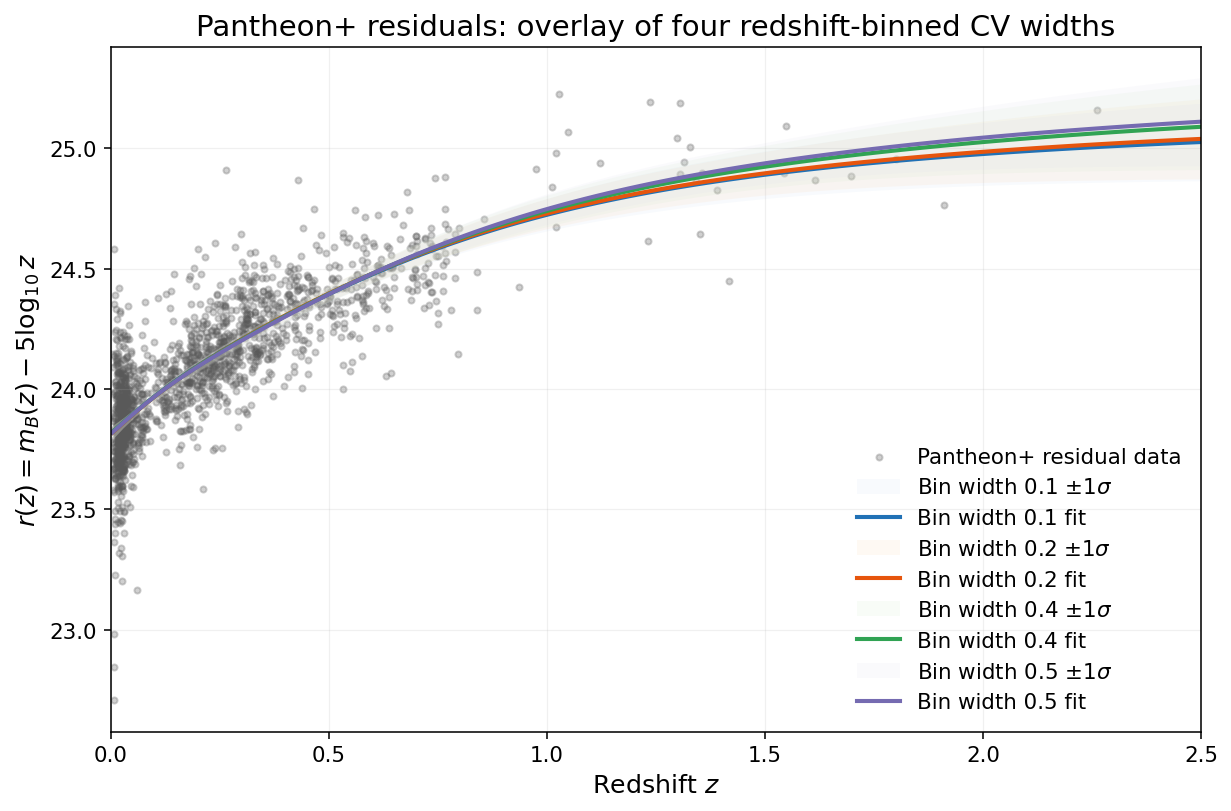

/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_width_rz_overlay.png
/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_width_rz_overlay.pdf


In [2]:
fig, ax = plt.subplots(figsize=(8.9, 5.9))

ax.scatter(
    pantheon['zHD'],
    pantheon['r_of_z'],
    s=10,
    color='0.35',
    alpha=0.28,
    zorder=0,
    label='Pantheon+ residual data',
)

for label, info in variant_info.items():
    table = variant_tables[label]
    ax.fill_between(
        table['z'],
        table['r_mean'] - table['m_b_sigma'],
        table['r_mean'] + table['m_b_sigma'],
        color=info['band'],
        alpha=0.12,
        linewidth=0.0,
        label=f'{label} ' + r'$\pm 1\sigma$',
    )
    ax.plot(
        table['z'],
        table['r_mean'],
        color=info['line'],
        lw=2.1,
        label=f'{label} fit',
    )

ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$r(z) = m_B(z) - 5\log_{10} z$')
ax.set_title(r'Pantheon+ residuals: overlay of four redshift-binned CV widths')
ax.grid(alpha=0.18, linewidth=0.6)
ax.legend(frameon=False, loc='lower right')

out_png = comparison_dir / 'binnedcv_width_rz_overlay.png'
out_pdf = comparison_dir / 'binnedcv_width_rz_overlay.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


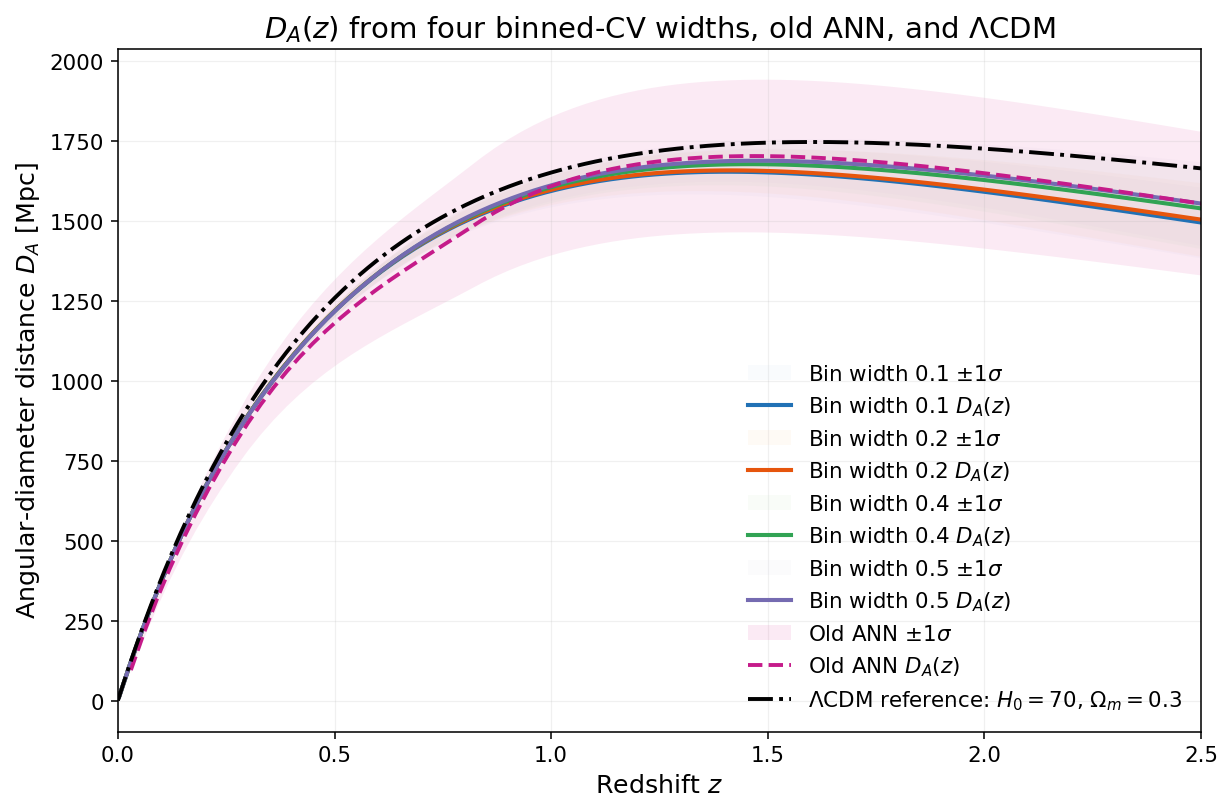

/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_width_da_vs_lcdm.png
/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_width_da_vs_lcdm.pdf


In [3]:
M_assumed = -19.3
c_km_s = 299792.458
h0 = 70.0
omega_m = 0.3
omega_l = 1.0 - omega_m

old_curve = np.load(root_dir / 'output' / 'old_ann' / 'rec_curve.npy')
old_z = old_curve[:, 0]
old_da = old_curve[:, 1]
old_da_sigma = old_curve[:, 2]

fig, ax = plt.subplots(figsize=(8.9, 5.9))

for label, info in variant_info.items():
    table = variant_tables[label].copy()
    dl_mpc = 10.0 ** ((table['m_b_mean'].to_numpy() - M_assumed - 25.0) / 5.0)
    da_mpc = dl_mpc / (1.0 + table['z'].to_numpy()) ** 2
    da_sigma = da_mpc * (np.log(10.0) / 5.0) * table['m_b_sigma'].to_numpy()

    ax.fill_between(
        table['z'],
        da_mpc - da_sigma,
        da_mpc + da_sigma,
        color=info['band'],
        alpha=0.10,
        linewidth=0.0,
        label=f'{label} ' + r'$\pm 1\sigma$',
    )
    ax.plot(
        table['z'],
        da_mpc,
        color=info['line'],
        lw=2.1,
        label=f'{label} $D_A(z)$',
    )

ax.fill_between(
    old_z,
    old_da - old_da_sigma,
    old_da + old_da_sigma,
    color='#dd3497',
    alpha=0.10,
    linewidth=0.0,
    label='Old ANN ' + r'$\pm 1\sigma$',
)
ax.plot(
    old_z,
    old_da,
    color='#c51b8a',
    lw=2.0,
    linestyle='--',
    label='Old ANN $D_A(z)$',
)

z_ref = np.linspace(0.0, 2.5, 400)
ez = np.sqrt(omega_m * (1.0 + z_ref) ** 3 + omega_l)
dc = np.zeros_like(z_ref)
if z_ref.size > 1:
    dc[1:] = (c_km_s / h0) * np.cumsum(0.5 * (1.0 / ez[1:] + 1.0 / ez[:-1]) * np.diff(z_ref))
da_ref = dc / (1.0 + z_ref)
ax.plot(
    z_ref,
    da_ref,
    color='black',
    lw=2.0,
    linestyle='-.',
    label=r'$\Lambda$CDM reference: $H_0=70$, $\Omega_m=0.3$',
)

ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'Angular-diameter distance $D_A$ [Mpc]')
ax.set_title(r'$D_A(z)$ from four binned-CV widths, old ANN, and $\Lambda$CDM')
ax.grid(alpha=0.18, linewidth=0.6)
ax.legend(frameon=False, loc='lower right')

out_png = comparison_dir / 'binnedcv_width_da_vs_lcdm.png'
out_pdf = comparison_dir / 'binnedcv_width_da_vs_lcdm.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


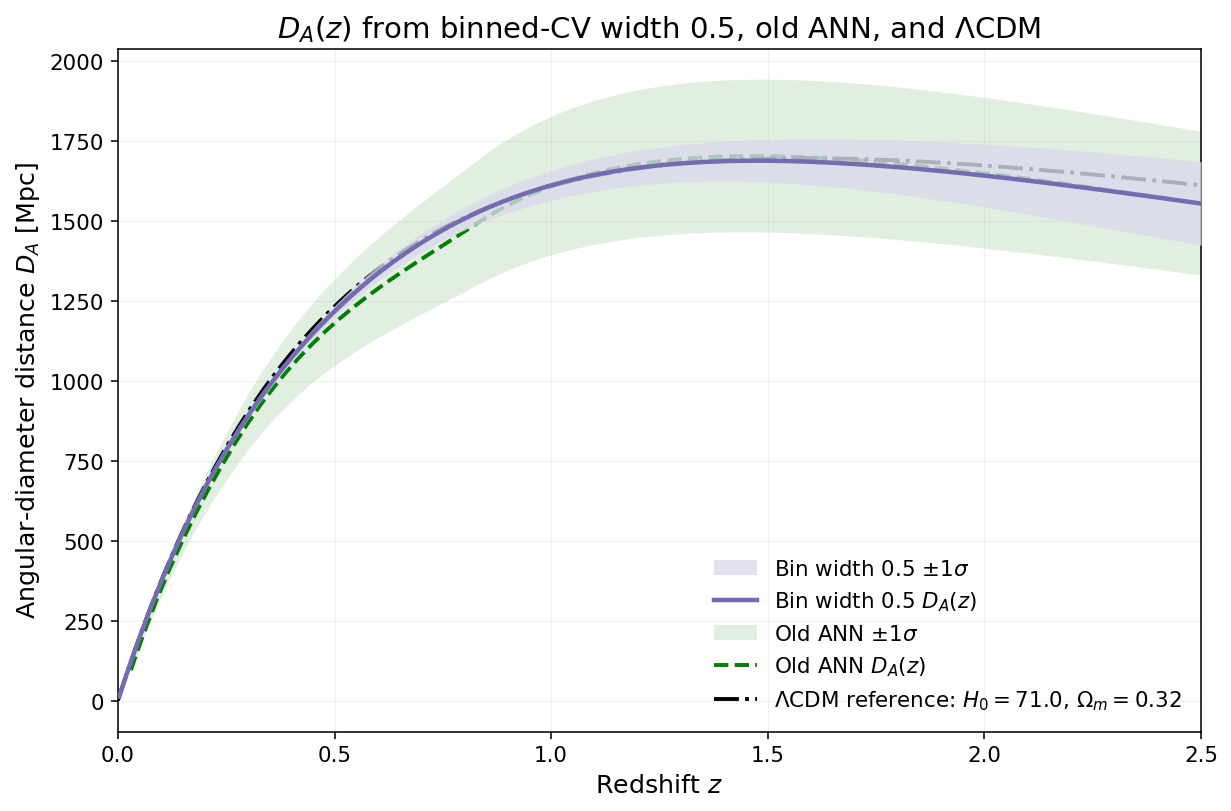

/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_bw05_da_vs_lcdm.png
/home/geng/Codes/sgl_cosmo/ann/output/binnedcv_width_comparison/binnedcv_bw05_da_vs_lcdm.pdf


In [8]:
M_assumed = -19.3
c_km_s = 299792.458
h0 = 71.0
omega_m = 0.32
omega_l = 1.0 - omega_m

table = variant_tables['Bin width 0.5'].copy()
info = variant_info['Bin width 0.5']
old_curve = np.load(root_dir / 'output' / 'old_ann' / 'rec_curve.npy')
old_z = old_curve[:, 0]
old_da = old_curve[:, 1]
old_da_sigma = old_curve[:, 2]

fig, ax = plt.subplots(figsize=(8.9, 5.9))

dl_mpc = 10.0 ** ((table['m_b_mean'].to_numpy() - M_assumed - 25.0) / 5.0)
da_mpc = dl_mpc / (1.0 + table['z'].to_numpy()) ** 2
da_sigma = da_mpc * (np.log(10.0) / 5.0) * table['m_b_sigma'].to_numpy()

ax.fill_between(
    table['z'],
    da_mpc - da_sigma,
    da_mpc + da_sigma,
    color=info['band'],
    alpha=0.8,
    linewidth=0.0,
    label='Bin width 0.5 ' + r'$\pm 1\sigma$',
    zorder=10,
)
ax.plot(
    table['z'],
    da_mpc,
    color=info['line'],
    lw=2.3,
    label='Bin width 0.5 $D_A(z)$',
    zorder=10,
)

ax.fill_between(
    old_z,
    old_da - old_da_sigma,
    old_da + old_da_sigma,
    color='green',
    alpha=0.12,
    linewidth=0.0,
    label='Old ANN ' + r'$\pm 1\sigma$',
)
ax.plot(
    old_z,
    old_da,
    color='green',
    lw=2.0,
    linestyle='--',
    label='Old ANN $D_A(z)$',
)

z_ref = np.linspace(0.0, 2.5, 400)
ez = np.sqrt(omega_m * (1.0 + z_ref) ** 3 + omega_l)
dc = np.zeros_like(z_ref)
if z_ref.size > 1:
    dc[1:] = (c_km_s / h0) * np.cumsum(0.5 * (1.0 / ez[1:] + 1.0 / ez[:-1]) * np.diff(z_ref))
da_ref = dc / (1.0 + z_ref)
ax.plot(
    z_ref,
    da_ref,
    color='black',
    lw=2.0,
    linestyle='-.',
    label=r'$\Lambda$CDM reference: $H_0=71.0$, $\Omega_m=0.32$',
)

ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'Angular-diameter distance $D_A$ [Mpc]')
ax.set_title(r'$D_A(z)$ from binned-CV width 0.5, old ANN, and $\Lambda$CDM')
ax.grid(alpha=0.18, linewidth=0.6)
ax.legend(frameon=False, loc='lower right')

out_png = comparison_dir / 'binnedcv_bw05_da_vs_lcdm.png'
out_pdf = comparison_dir / 'binnedcv_bw05_da_vs_lcdm.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)
